**Load Tools**

In [1]:
!pip install tensorflow
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")

import re
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud 
nltk.download("stopwords")
stopword = set(stopwords.words("english"))

import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv1D,Dense,Dropout,GlobalMaxPooling1D,Embedding,BatchNormalization,Flatten,MaxPool1D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model
tf.random.set_seed(44)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2025-11-19 16:43:32.860764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763570613.099471      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763570613.164571      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Load Data**

In [3]:
data = pd.read_csv("/kaggle/input/text-classification/bbc-text.csv")
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [4]:
print(f"Data Contain Number of {data.shape[0]} Rows & {data.shape[1]} Columns")

Data Contain Number of 2225 Rows & 2 Columns


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [6]:
data.isnull().sum()

category    0
text        0
dtype: int64

In [7]:
data.describe()

,category,text
count,2225,2225
unique,5,2126
top,sport,blind student hears in colour a blind studen...
freq,511,2


**EDA**

In [8]:
data.category.value_counts().to_frame()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


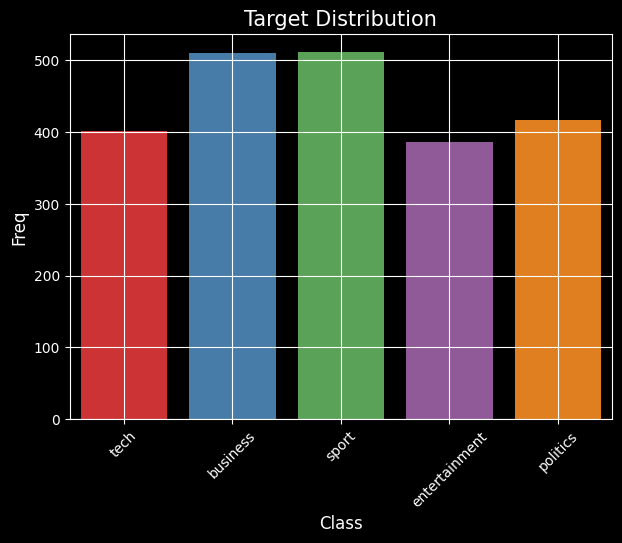

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(x="category",data=data,palette="Set1")
plt.title("Target Distribution",fontsize=15)
plt.xticks(rotation=45)
plt.xlabel("Class",fontsize=12)
plt.ylabel("Freq",fontsize=12)
plt.grid(True)
plt.show()

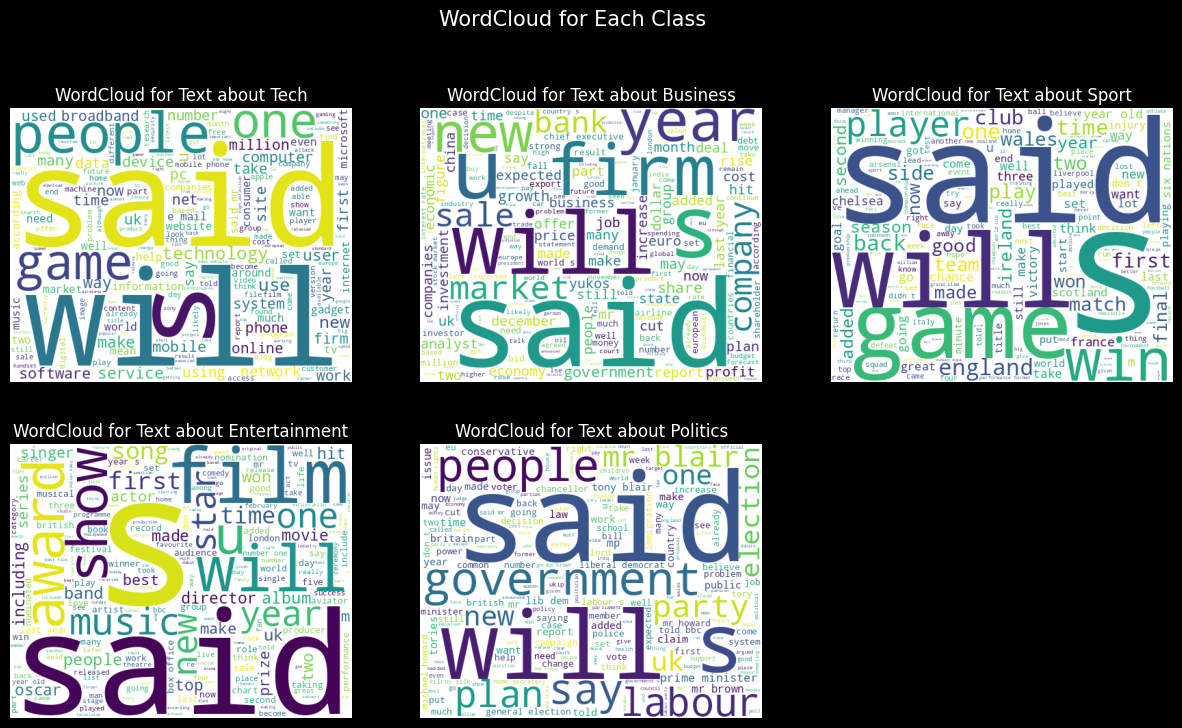

In [10]:
plt.figure(figsize=(15,8))
for i,class_name in enumerate(data.category.unique()):
    ax = plt.subplot(2,3,i+1)
    text = data.text[data.category==class_name]
    ax.imshow(WordCloud(background_color="white",width=500,height=400).generate(" ".join(text)))
    ax.axis("off")
    plt.title(f"WordCloud for Text about {class_name.capitalize()}",fontsize=12)
plt.suptitle("WordCloud for Each Class",fontsize=15,y=1)
plt.show()  

**Preprocessing**

In [11]:
def Clean_Data(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]"," ",text)
    stemmer = PorterStemmer()
    words =[stemmer.stem(word) for word in word_tokenize(text) if word not in stopword]
    return " ".join(words)

In [12]:
data["cleaned_text"] = data.text.apply(Clean_Data)
data.head()

,category,text,cleaned_text
0,tech,tv future in the hands of viewers with home th...,tv futur hand viewer home theatr system plasma...
1,business,worldcom boss left books alone former worldc...,worldcom boss left book alon former worldcom b...
2,sport,tigers wary of farrell gamble leicester say ...,tiger wari farrel gambl leicest say rush make ...
3,sport,yeading face newcastle in fa cup premiership s...,yead face newcastl fa cup premiership side new...
4,entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelv raid box offic ocean twelv crime c...


In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data.cleaned_text)
X = tokenizer.texts_to_sequences(data.cleaned_text)
vocb_size = len(tokenizer.word_index)+1
max_length = max([len(x) for x in X])
print(f"Vocb Size: {vocb_size} & Max length: {max_length}")

Vocb Size: 18998 & Max length: 2198


In [14]:
max_length = 1000
X = pad_sequences(X,padding="post",maxlen=max_length)
X

array([[ 112,  220,  301, ...,    0,    0,    0],
       [1474,  583,  322, ...,    0,    0,    0],
       [2539, 5019, 2989, ...,    0,    0,    0],
       ...,
       [4412,  193,    7, ...,    0,    0,    0],
       [ 244, 3453, 9918, ...,    0,    0,    0],
       [2122, 1583,  370, ...,    0,    0,    0]], dtype=int32)

In [15]:
encoder = LabelEncoder()
y = encoder.fit_transform(data.category)
y

array([4, 0, 3, ..., 1, 2, 3])

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=44,shuffle=True,stratify=y)
print(f"X Train Shape: {X_train.shape} & X Test Shape: {X_test.shape}")
print(f"Y Train Shape: {y_train.shape} & Y Test Shape: {y_test.shape}")

X Train Shape: (1780, 1000) & X Test Shape: (445, 1000)
Y Train Shape: (1780,) & Y Test Shape: (445,)


**CNN Model**

In [17]:
model = Sequential()
model.add(Embedding(input_dim=vocb_size,output_dim=128,input_length=max_length))
model.add(Conv1D(256,5,activation="relu"))
model.add(MaxPool1D())
model.add(Dropout(.2))
#model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(.2))
model.add(Dense(64,activation="relu"))
model.add(Dense(len(data.category.unique()),activation="softmax"))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1763570643.521191      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping = EarlyStopping(monitor="val_loss",min_delta=.001,patience=3,restore_best_weights=True)
check_point = ModelCheckpoint("bbc.keras",monitor="val_loss",save_best_only=True)
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history = model.fit(
    X_train,
    y_train,
    validation_split=.2,
    epochs=20,
    #batch_size=32,
    callbacks=[early_stopping,check_point]
)

Epoch 1/20


I0000 00:00:1763570646.264464      73 service.cc:148] XLA service 0x7e188800b660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763570646.265296      73 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763570646.682798      73 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/45 ━━━━━━━━━━━━━━━━━━━━ 4:56 7s/step - accuracy: 0.3125 - loss: 1.6059

I0000 00:00:1763570650.403264      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.2863 - loss: 1.5564 - val_accuracy: 0.7303 - val_loss: 0.7050
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8262 - loss: 0.4792 - val_accuracy: 0.9663 - val_loss: 0.1277
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9810 - loss: 0.0500 - val_accuracy: 0.9551 - val_loss: 0.1606
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9988 - loss: 0.0086 - val_accuracy: 0.9551 - val_loss: 0.1378
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9635 - val_loss: 0.1272


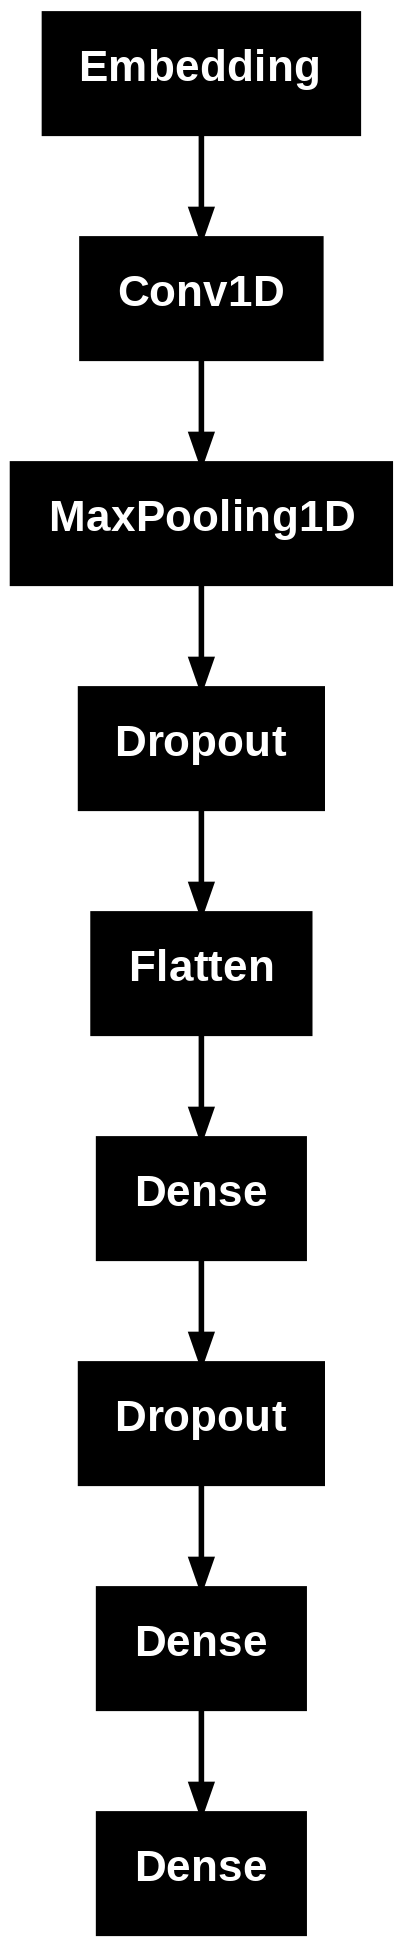

In [19]:
plot_model(model)

In [20]:
hist = pd.DataFrame(history.history)
hist

,accuracy,loss,val_accuracy,val_loss
0,0.386938,1.405711,0.730337,0.704985
1,0.892556,0.306891,0.966292,0.127749
2,0.992275,0.026432,0.955056,0.160646
3,0.998595,0.006659,0.955056,0.137846
4,1.000000,0.002019,0.963483,0.127165


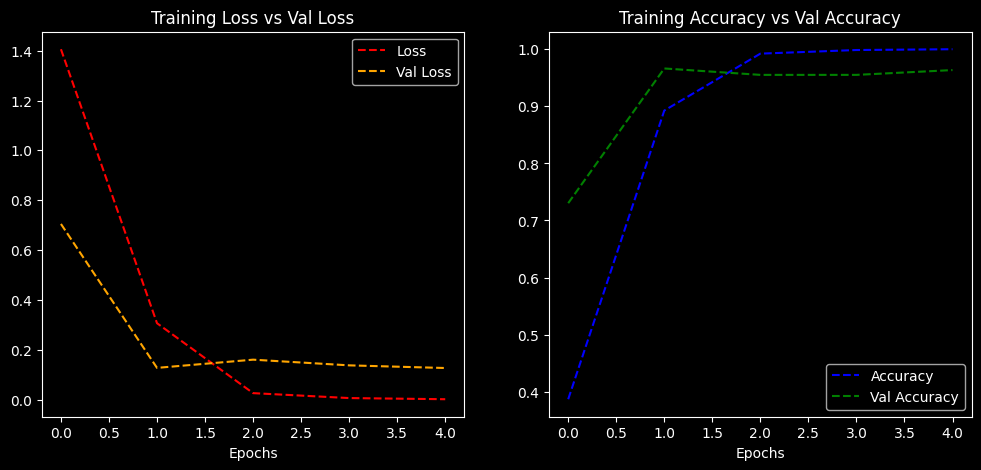

In [21]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist["loss"],'--',color="red")
plt.plot(hist["val_loss"],'--',color="orange")
plt.legend(["Loss","Val Loss"])
plt.title("Training Loss vs Val Loss",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.subplot(1,2,2)
plt.plot(hist["accuracy"],'--',color="blue")
plt.plot(hist["val_accuracy"],'--',color="green")
plt.legend(["Accuracy","Val Accuracy"])
plt.title("Training Accuracy vs Val Accuracy",fontsize=12)
plt.xlabel("Epochs",fontsize=10)
plt.show()

**Evaluation**

In [22]:
model = load_model("bbc.keras")

In [23]:
loss,acc = model.evaluate(X_test,y_test)
print(f"Test Loss: {loss} , Test Accuracy: {acc}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9444 - loss: 0.2496
Test Loss: 0.23965969681739807 , Test Accuracy: 0.9505618214607239


In [24]:
y_pred = np.argmax(model.predict(X_test),axis=1)
y_pred[:5]

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


array([2, 3, 3, 4, 3])

In [25]:
y_pred_names = encoder.inverse_transform(y_pred)
pd.DataFrame({"Actual":y_test,"Prediction":y_pred,"Name":y_pred_names})

,Actual,Prediction,Name
0,2,2,politics
1,3,3,sport
2,3,3,sport
3,4,4,tech
4,3,3,sport
...,...,...,...
440,2,2,politics
441,0,0,business
442,2,2,politics
443,0,0,business


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


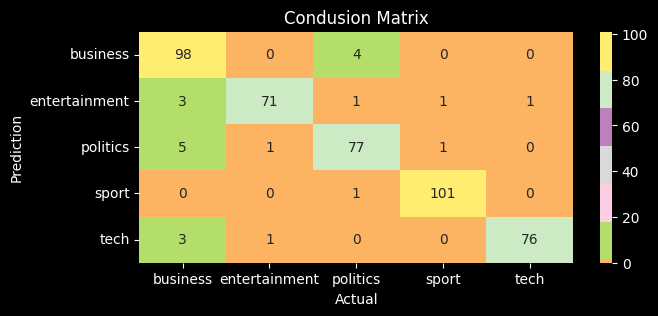

array([[ 98,   0,   4,   0,   0],
       [  3,  71,   1,   1,   1],
       [  5,   1,  77,   1,   0],
       [  0,   0,   1, 101,   0],
       [  3,   1,   0,   0,  76]])

In [26]:
CM = confusion_matrix(y_test,y_pred)
class_names = encoder.classes_
plt.figure(figsize=(7,3))
sns.heatmap(CM,annot=True,fmt="g",center=True,cmap="Set3",xticklabels=class_names,yticklabels=class_names)
plt.title("Condusion Matrix",fontsize=12)
plt.xlabel("Actual",fontsize=10)
plt.ylabel("Prediction",fontsize=10)
plt.show()
CM

In [27]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=class_names))

Classification Report:
                precision    recall  f1-score   support

     business       0.90      0.96      0.93       102
entertainment       0.97      0.92      0.95        77
     politics       0.93      0.92      0.92        84
        sport       0.98      0.99      0.99       102
         tech       0.99      0.95      0.97        80

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.95      0.95      0.95       445

